# 19 — US Portfolio Diversification Analysis

## Purpose

Test whether the EM hedged strategy (All6-EW + TO_MVO, EEM-hedged) provides
meaningful **diversification value** for a US equity investor. We answer:

1. **Hurdle Sharpe Test**: Is the EM strategy's Sharpe ratio high enough to
   justify adding it to a US portfolio, given its correlation with US equities?
2. **Hurdle Alpha Test**: Does the strategy deliver positive alpha after
   controlling for US factor exposures (CAPM, FF3, FF5, FF5+Mom)?
3. **US Factor Loadings**: What are the strategy's exposures to US factors,
   and how do they compare with EM factor exposures from NB17?
4. **Optimal Allocation**: What weight should a US investor allocate to
   the EM hedged strategy (risk aversion $\lambda=2.5$)?
5. **Sub-Period Stability**: Are these diversification benefits stable
   across different market regimes?

### Data

- **EM Strategy Returns**: `nb09_hedged_returns.csv` (OOS 2019-01 to 2024-09)
- **US Fama-French 5 Factors + Momentum**: `us_ff6_factors.csv` (Ken French Data Library)
- **EM Fama-French 5 Factors + Momentum**: `em_ff6_factors.csv` (for comparison)

### Econometric Specifications

**Hedged strategy**: $R_{h,t} = \alpha + \sum_{k} \beta_k F^{US}_{k,t} + \varepsilon_t$

**Long-only excess**: $R_{p,t} - R^{US}_{f,t} = \alpha + \sum_{k} \beta_k F^{US}_{k,t} + \varepsilon_t$

## 1. Setup and Data Loading

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

OUTPUT_DIR = '../output'
OOS_START = pd.Timestamp('2019-01-01')
OOS_END   = pd.Timestamp('2024-09-01')

def ann_sharpe(s):
    return s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else 0.0

# --- Load EM strategy returns ---
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv',
                  index_col=0, parse_dates=True)

# --- Load US FF5 + Momentum ---
us_ff = pd.read_csv('../data/us_ff6_factors.csv', index_col=0, parse_dates=True)
us_ff.columns = [c.strip() for c in us_ff.columns]
us_ff.rename(columns={'Mkt-RF': 'Mkt_RF'}, inplace=True)

# --- Load EM FF5 + Momentum (for comparison) ---
em_ff = pd.read_csv('../data/em_ff6_factors.csv', index_col=0, parse_dates=True)
em_ff.columns = [c.strip() for c in em_ff.columns]
em_ff.rename(columns={'Mkt-RF': 'Mkt_RF'}, inplace=True)

# --- Filter to OOS period ---
mask_oos = (hdf.index >= OOS_START) & (hdf.index <= OOS_END)
strat = hdf.loc[mask_oos].copy()
us = us_ff.loc[(us_ff.index >= OOS_START) & (us_ff.index <= OOS_END)].copy()
em = em_ff.loc[(em_ff.index >= OOS_START) & (em_ff.index <= OOS_END)].copy()

# Align all on common dates
common_idx = strat.index.intersection(us.index).intersection(em.index)
strat = strat.loc[common_idx]
us = us.loc[common_idx]
em = em.loc[common_idx]

# Compute excess returns for long-only strategies (subtract US RF)
strat['A_long_excess'] = strat['A_long'] - us['RF']
strat['B_long_excess'] = strat['B_long'] - us['RF']

# US market total return = Mkt_RF + RF
us['Mkt_total'] = us['Mkt_RF'] + us['RF']

STRATEGIES = {
    'TO_MVO Long-Only': 'A_long_excess',
    'TO_MVO Hedged':    'A_hedged_eem',
    'Mom Long-Only':    'B_long_excess',
    'Mom Hedged':       'B_hedged_eem',
}

US_FACTORS = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

print(f'OOS Period: {common_idx.min().strftime("%Y-%m")} to {common_idx.max().strftime("%Y-%m")} ({len(common_idx)} months)')
for name, col in STRATEGIES.items():
    n_obs = strat[col].dropna().shape[0]
    print(f'  {name:25s} obs: {n_obs}')

OOS Period: 2019-01 to 2024-09 (69 months)
  TO_MVO Long-Only          obs: 69
  TO_MVO Hedged             obs: 69
  Mom Long-Only             obs: 69
  Mom Hedged                obs: 69


## 2. US Market Characterization

In [2]:
# US factor summary statistics (OOS period)
us_stats = pd.DataFrame({
    'Mean (ann %)': us[US_FACTORS].mean() * 1200,
    'Std (ann %)':  us[US_FACTORS].std() * np.sqrt(12) * 100,
    'Sharpe':       us[US_FACTORS].mean() / us[US_FACTORS].std() * np.sqrt(12),
    't-stat':       us[US_FACTORS].mean() / (us[US_FACTORS].std() / np.sqrt(len(us))),
    'Min (%)':      us[US_FACTORS].min() * 100,
    'Max (%)':      us[US_FACTORS].max() * 100,
})

em_stats = pd.DataFrame({
    'Mean (ann %)': em[US_FACTORS].mean() * 1200,
    'Std (ann %)':  em[US_FACTORS].std() * np.sqrt(12) * 100,
    'Sharpe':       em[US_FACTORS].mean() / em[US_FACTORS].std() * np.sqrt(12),
    't-stat':       em[US_FACTORS].mean() / (em[US_FACTORS].std() / np.sqrt(len(em))),
})

print('=' * 80)
print('US FAMA-FRENCH FACTOR SUMMARY STATISTICS (OOS Period)')
print('=' * 80)
print(us_stats.round(3).to_string())

print()
print('=' * 80)
print('EM FAMA-FRENCH FACTOR SUMMARY STATISTICS (OOS Period, for comparison)')
print('=' * 80)
print(em_stats.round(3).to_string())

# Side-by-side comparison
comparison = pd.DataFrame({
    'US Mean (ann %)': us[US_FACTORS].mean() * 1200,
    'EM Mean (ann %)': em[US_FACTORS].mean() * 1200,
    'US Sharpe':       us[US_FACTORS].mean() / us[US_FACTORS].std() * np.sqrt(12),
    'EM Sharpe':       em[US_FACTORS].mean() / em[US_FACTORS].std() * np.sqrt(12),
})
print()
print('SIDE-BY-SIDE COMPARISON')
print(comparison.round(3).to_string())

US FAMA-FRENCH FACTOR SUMMARY STATISTICS (OOS Period)
        Mean (ann %)  Std (ann %)  Sharpe  t-stat  Min (%)  Max (%)
Mkt_RF        15.226       18.229   0.835   2.003   -13.35    13.58
SMB           -2.341       11.279  -0.208  -0.498    -8.18     8.34
HML           -1.315       15.748  -0.083  -0.200   -13.83    12.86
RMW            7.346        8.404   0.874   2.096    -4.78     7.19
CMA            0.343        9.743   0.035   0.084    -7.08     7.73
Mom            0.803       15.525   0.052   0.124   -16.17     8.21

EM FAMA-FRENCH FACTOR SUMMARY STATISTICS (OOS Period, for comparison)
        Mean (ann %)  Std (ann %)  Sharpe  t-stat
Mkt_RF         6.285       17.368   0.362   0.868
SMB            0.614        5.344   0.115   0.275
HML            8.732        8.985   0.972   2.331
RMW            2.409        4.618   0.522   1.251
CMA            2.228        6.954   0.320   0.768
Mom           12.050       10.002   1.205   2.889

SIDE-BY-SIDE COMPARISON
        US Mean (ann %) 

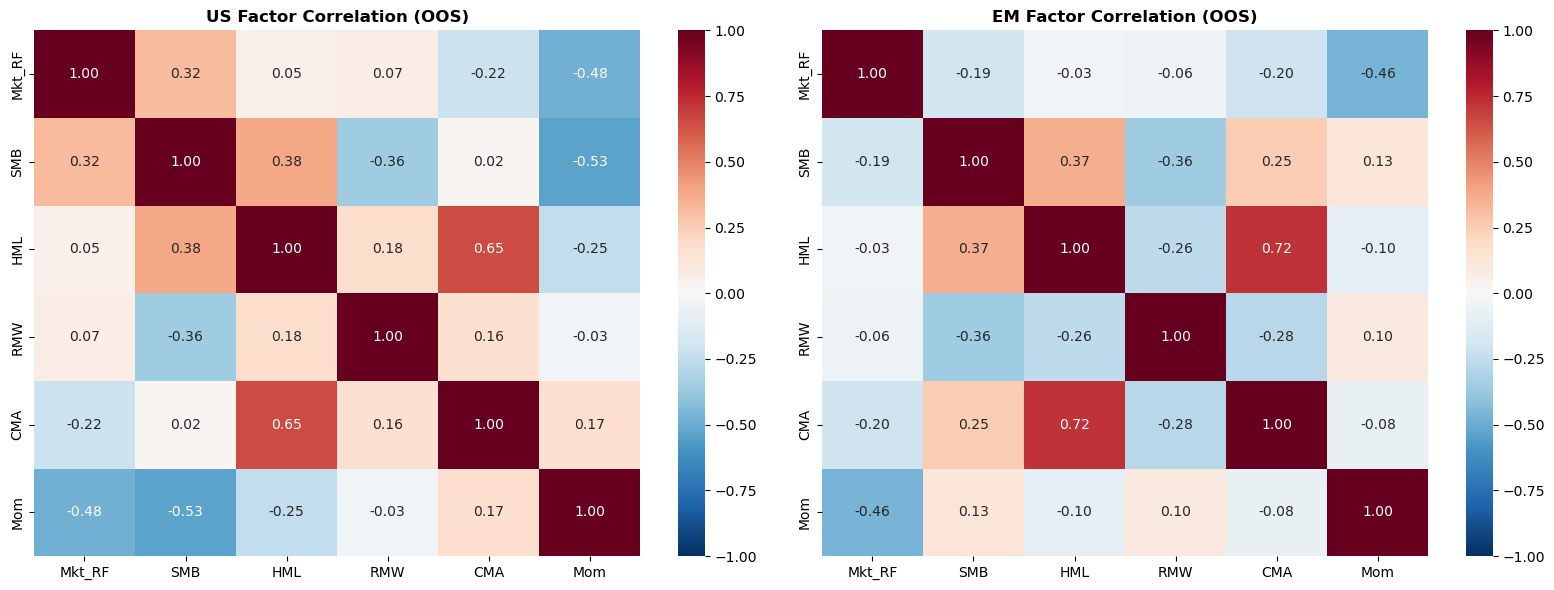

In [3]:
# US factor correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_us = us[US_FACTORS].corr()
sns.heatmap(corr_us, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('US Factor Correlation (OOS)', fontweight='bold')

corr_em = em[US_FACTORS].corr()
sns.heatmap(corr_em, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('EM Factor Correlation (OOS)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_factor_correlation.pdf', bbox_inches='tight')
plt.show()

## 3. Correlation Analysis: EM Strategies vs US Factors

CORRELATION: EM Strategies vs US Factors (OOS)
                  Mkt_RF    SMB    HML    RMW    CMA    Mom  US_Mkt_Total
TO_MVO Long-Only   0.736  0.336  0.118 -0.002  0.020 -0.462         0.736
TO_MVO Hedged      0.223  0.012 -0.077  0.100  0.103 -0.052         0.220
Mom Long-Only      0.729  0.330  0.086 -0.040  0.008 -0.424         0.727
Mom Hedged         0.224  0.017 -0.163 -0.018  0.069  0.047         0.215


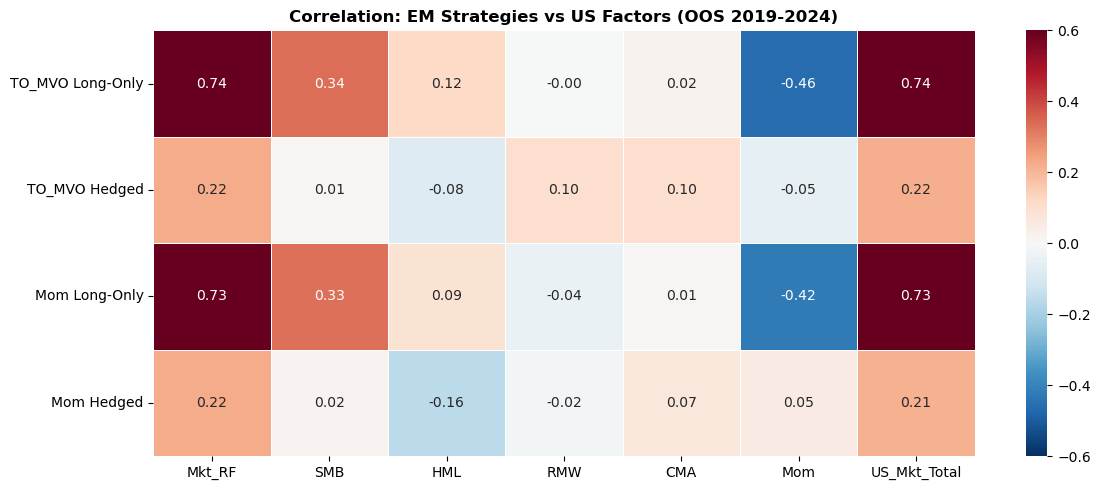


TO_MVO Hedged correlation with US Mkt-RF: 0.223

Mom Hedged correlation with US Mkt-RF: 0.224


In [4]:
# Build correlation matrix: EM strategies vs US factors
strat_cols = {n: strat[c].dropna() for n, c in STRATEGIES.items()}

corr_data = pd.DataFrame(index=list(STRATEGIES.keys()),
                         columns=US_FACTORS + ['US_Mkt_Total'])

for sname, scol in STRATEGIES.items():
    s = strat[scol].dropna()
    cidx = s.index.intersection(us.index)
    for f in US_FACTORS:
        corr_data.loc[sname, f] = s.loc[cidx].corr(us.loc[cidx, f])
    corr_data.loc[sname, 'US_Mkt_Total'] = s.loc[cidx].corr(us.loc[cidx, 'Mkt_total'])

corr_data = corr_data.astype(float)

print('CORRELATION: EM Strategies vs US Factors (OOS)')
print(corr_data.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(corr_data.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6, ax=ax, linewidths=0.5)
ax.set_title('Correlation: EM Strategies vs US Factors (OOS 2019-2024)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_correlation_matrix.pdf', bbox_inches='tight')
plt.show()

# Key insight: hedged strategies should have low US market correlation
for sn in ['TO_MVO Hedged', 'Mom Hedged']:
    rho = corr_data.loc[sn, 'Mkt_RF']
    print(f'\n{sn} correlation with US Mkt-RF: {rho:.3f}')

## 4. Hurdle Sharpe Test

A new asset is worth adding to a portfolio if its Sharpe ratio exceeds the
**hurdle Sharpe**: $\text{SR}_{\text{hurdle}} = \text{SR}_{\text{US}} \times \rho(R_{\text{EM}}, R_{\text{US}})$.

The **diversification premium** is:
$\Delta\text{SR} = \text{SR}_{\text{EM}} - \text{SR}_{\text{US}} \times \rho$

US Market Sharpe (OOS): 0.835

HURDLE SHARPE TEST: Is EM strategy worth adding to a US portfolio?
                  SR_EM  rho(EM, US_Mkt)  Hurdle SR  Premium Pass
Strategy                                                         
TO_MVO Long-Only  0.490            0.736      0.615   -0.125   NO
TO_MVO Hedged     0.828            0.223      0.187    0.642  YES
Mom Long-Only     0.475            0.729      0.609   -0.135   NO
Mom Hedged        0.795            0.224      0.187    0.608  YES


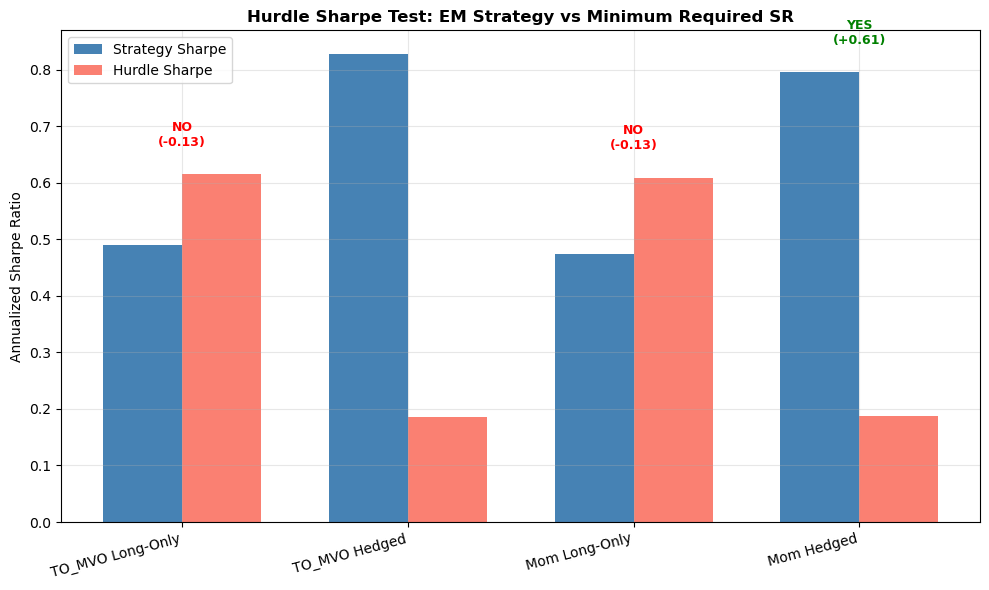

In [5]:
sr_us_mkt = ann_sharpe(us['Mkt_RF'])
print(f'US Market Sharpe (OOS): {sr_us_mkt:.3f}')
print()

hurdle_results = []
for sname, scol in STRATEGIES.items():
    s = strat[scol].dropna()
    cidx = s.index.intersection(us.index)
    sr_em = ann_sharpe(s.loc[cidx])
    rho = s.loc[cidx].corr(us.loc[cidx, 'Mkt_RF'])
    hurdle = sr_us_mkt * rho
    premium = sr_em - hurdle
    passed = sr_em > hurdle
    hurdle_results.append({
        'Strategy': sname,
        'SR_EM': sr_em,
        'rho(EM, US_Mkt)': rho,
        'Hurdle SR': hurdle,
        'Premium': premium,
        'Pass': 'YES' if passed else 'NO',
    })

hurdle_df = pd.DataFrame(hurdle_results).set_index('Strategy')
print('=' * 85)
print('HURDLE SHARPE TEST: Is EM strategy worth adding to a US portfolio?')
print('=' * 85)
print(hurdle_df.round(3).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(hurdle_df))
w = 0.35
ax.bar(x - w/2, hurdle_df['SR_EM'], w, label='Strategy Sharpe', color='steelblue')
ax.bar(x + w/2, hurdle_df['Hurdle SR'], w, label='Hurdle Sharpe', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(hurdle_df.index, rotation=15, ha='right')
ax.set_ylabel('Annualized Sharpe Ratio')
ax.set_title('Hurdle Sharpe Test: EM Strategy vs Minimum Required SR', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3)

for i, row in enumerate(hurdle_df.itertuples()):
    color = 'green' if row.Pass == 'YES' else 'red'
    ax.annotate(f'{row.Pass}\n(+{row.Premium:.2f})' if row.Premium > 0 else f'{row.Pass}\n({row.Premium:.2f})',
                xy=(i, max(row.SR_EM, row._3) + 0.05),
                ha='center', fontweight='bold', color=color, fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_hurdle_sharpe.pdf', bbox_inches='tight')
plt.show()

## 5. Hurdle Alpha Test

The hurdle alpha test asks: after controlling for US factor exposures
(FF5+Mom), does the EM strategy still deliver statistically significant alpha?

We also compute:
- **Monthly alpha hit rate**: fraction of months with positive alpha contribution
- **Rolling 24-month alpha**: time series of alpha from rolling regressions

In [6]:
# Full-period US factor regressions (FF5+Mom) for all strategies
print('=' * 90)
print('US FACTOR REGRESSIONS (FF5+Mom) — OOS Period')
print('=' * 90)

alpha_results = []
for sname, scol in STRATEGIES.items():
    y = strat[scol].dropna()
    cidx = y.index.intersection(us.index)
    y = y.loc[cidx]
    X = sm.add_constant(us.loc[cidx, US_FACTORS])
    model = sm.OLS(y, X).fit(cov_type='HC1')
    
    alpha_ann = model.params['const'] * 12
    alpha_t = model.tvalues['const']
    r2 = model.rsquared
    
    # Monthly alpha hit rate: fraction of months with positive residual
    residuals = model.resid
    alpha_monthly = model.params['const'] + residuals
    hit_rate = (alpha_monthly > 0).mean()
    
    alpha_results.append({
        'Strategy': sname,
        'Alpha (ann bps)': alpha_ann * 10000,
        'Alpha t-stat': alpha_t,
        'Alpha p-val': model.pvalues['const'],
        'R-squared': r2,
        'Hit Rate': hit_rate,
        'Significant (5%)': 'YES' if model.pvalues['const'] < 0.05 else 'NO',
    })
    
    print(f'\n--- {sname} ---')
    print(f'  Alpha (ann):  {alpha_ann*100:.2f}% ({alpha_ann*10000:.0f} bps)')
    print(f'  t-stat:       {alpha_t:.2f} (p={model.pvalues["const"]:.4f})')
    print(f'  R-squared:    {r2:.3f}')
    print(f'  Hit rate:     {hit_rate:.1%}')

alpha_df = pd.DataFrame(alpha_results).set_index('Strategy')
print('\n')
print(alpha_df.round(3).to_string())
alpha_df.to_csv(f'{OUTPUT_DIR}/csv/nb19_alpha_results.csv')

US FACTOR REGRESSIONS (FF5+Mom) — OOS Period

--- TO_MVO Long-Only ---
  Alpha (ann):  -1.07% (-107 bps)
  t-stat:       -0.24 (p=0.8138)
  R-squared:    0.617
  Hit rate:     50.7%



--- TO_MVO Hedged ---
  Alpha (ann):  3.06% (306 bps)
  t-stat:       0.96 (p=0.3367)
  R-squared:    0.158
  Hit rate:     59.4%

--- Mom Long-Only ---
  Alpha (ann):  -1.13% (-113 bps)
  t-stat:       -0.24 (p=0.8123)
  R-squared:    0.603
  Hit rate:     50.7%

--- Mom Hedged ---
  Alpha (ann):  2.96% (296 bps)
  t-stat:       1.11 (p=0.2682)
  R-squared:    0.199
  Hit rate:     53.6%


                  Alpha (ann bps)  Alpha t-stat  Alpha p-val  R-squared  Hit Rate Significant (5%)
Strategy                                                                                          
TO_MVO Long-Only         -106.902        -0.236        0.814      0.617     0.507               NO
TO_MVO Hedged             305.584         0.961        0.337      0.158     0.594               NO
Mom Long-Only            -112.617        -0.237        0.812      0.603     0.507               NO
Mom Hedged                295.614         1.107        0.268      0.199     0.536               NO


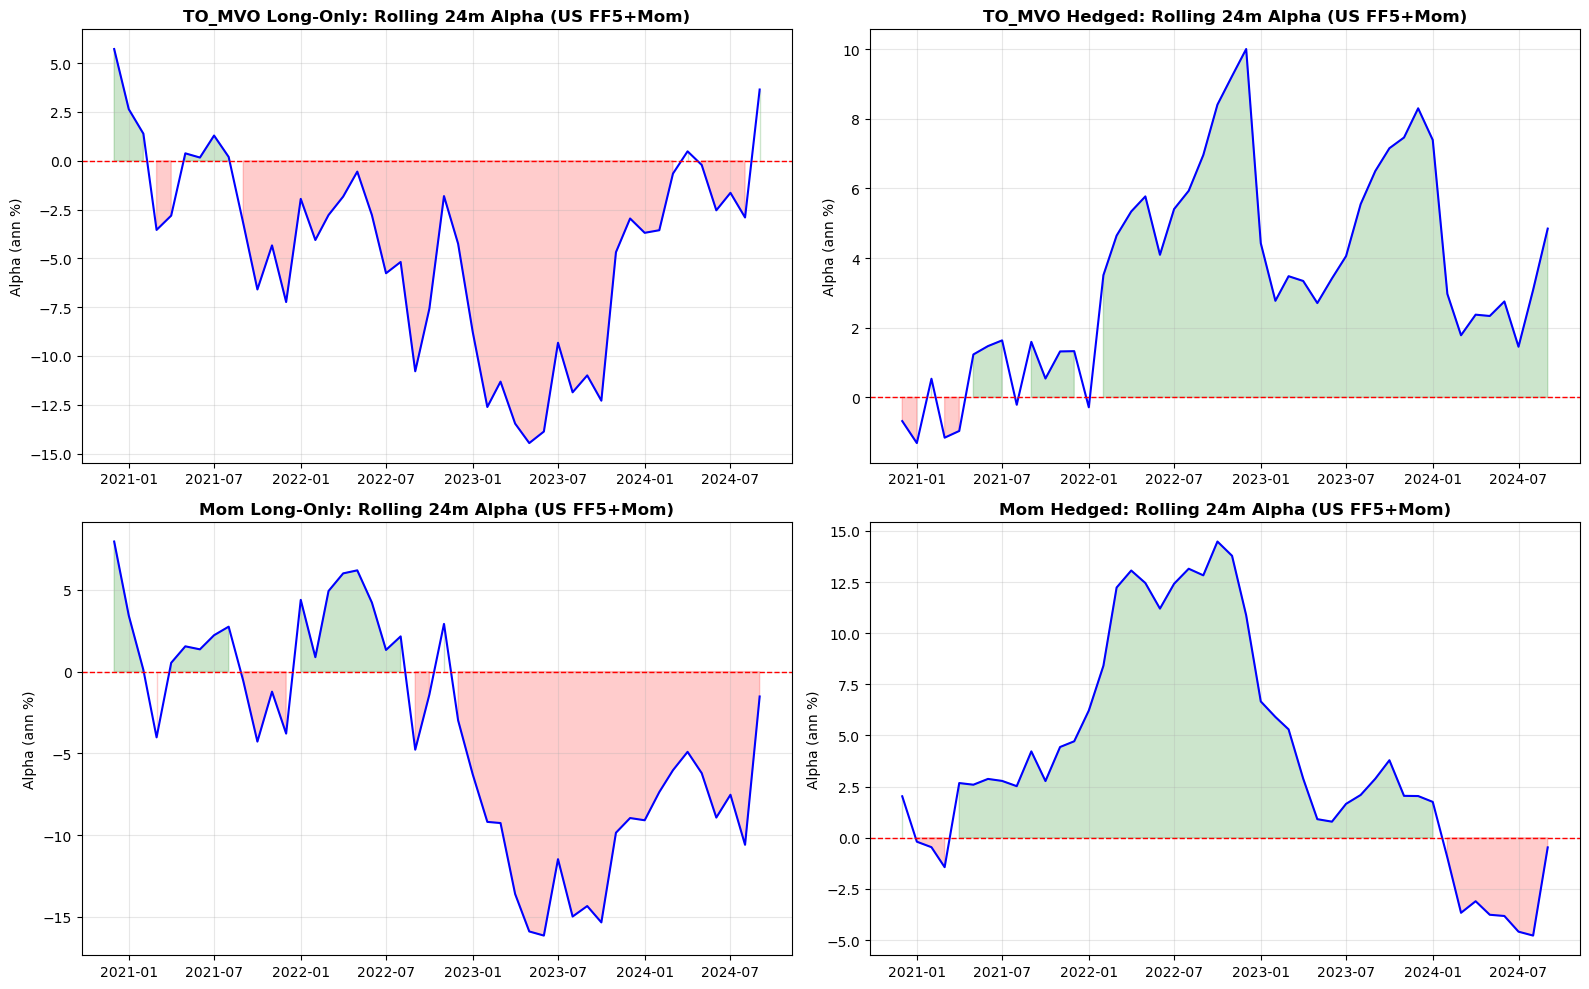

In [7]:
# Rolling 24-month alpha: US factor regression
ROLL_WIN = 24

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (sname, scol) in enumerate(STRATEGIES.items()):
    ax = axes[idx // 2, idx % 2]
    y_full = strat[scol].dropna()
    cidx = y_full.index.intersection(us.index)
    y_full = y_full.loc[cidx]
    X_full = us.loc[cidx, US_FACTORS]
    
    roll_alpha = []
    roll_dates = []
    for i in range(ROLL_WIN, len(cidx) + 1):
        window = cidx[i - ROLL_WIN:i]
        y_w = y_full.loc[window]
        X_w = sm.add_constant(X_full.loc[window])
        try:
            m = sm.OLS(y_w, X_w).fit()
            roll_alpha.append(m.params['const'] * 12 * 100)
            roll_dates.append(window[-1])
        except:
            pass
    
    ax.plot(roll_dates, roll_alpha, 'b-', lw=1.5)
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.fill_between(roll_dates, 0, roll_alpha,
                    where=[a > 0 for a in roll_alpha], alpha=0.2, color='green')
    ax.fill_between(roll_dates, 0, roll_alpha,
                    where=[a <= 0 for a in roll_alpha], alpha=0.2, color='red')
    ax.set_title(f'{sname}: Rolling {ROLL_WIN}m Alpha (US FF5+Mom)', fontweight='bold')
    ax.set_ylabel('Alpha (ann %)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_rolling_alpha_us.pdf', bbox_inches='tight')
plt.show()

In [8]:
# Compare US alpha vs EM alpha (from NB17 results)
print('ALPHA COMPARISON: US vs EM Factor Models')
print('=' * 70)

# Run EM factor regressions for comparison
EM_FACTORS = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']

for sname, scol in STRATEGIES.items():
    y = strat[scol].dropna()
    cidx_us = y.index.intersection(us.index)
    cidx_em = y.index.intersection(em.index)
    cidx = cidx_us.intersection(cidx_em)
    y_c = y.loc[cidx]
    
    # US regression
    X_us = sm.add_constant(us.loc[cidx, US_FACTORS])
    m_us = sm.OLS(y_c, X_us).fit(cov_type='HC1')
    
    # EM regression
    X_em = sm.add_constant(em.loc[cidx, EM_FACTORS])
    m_em = sm.OLS(y_c, X_em).fit(cov_type='HC1')
    
    print(f'\n{sname}:')
    print(f'  US Alpha (ann): {m_us.params["const"]*1200:.1f}%  (t={m_us.tvalues["const"]:.2f}, R²={m_us.rsquared:.3f})')
    print(f'  EM Alpha (ann): {m_em.params["const"]*1200:.1f}%  (t={m_em.tvalues["const"]:.2f}, R²={m_em.rsquared:.3f})')

ALPHA COMPARISON: US vs EM Factor Models

TO_MVO Long-Only:
  US Alpha (ann): -1.1%  (t=-0.24, R²=0.617)
  EM Alpha (ann): 2.2%  (t=0.78, R²=0.913)

TO_MVO Hedged:
  US Alpha (ann): 3.1%  (t=0.96, R²=0.158)
  EM Alpha (ann): 2.4%  (t=0.84, R²=0.171)

Mom Long-Only:
  US Alpha (ann): -1.1%  (t=-0.24, R²=0.603)
  EM Alpha (ann): 1.4%  (t=0.51, R²=0.916)

Mom Hedged:
  US Alpha (ann): 3.0%  (t=1.11, R²=0.199)
  EM Alpha (ann): 1.5%  (t=0.58, R²=0.330)


## 6. Comprehensive US Factor Loadings

Incremental regression tables: CAPM → FF3 → FF5 → FF5+Mom.
Run for all four strategies to understand how US factor exposures evolve.

In [9]:
# Incremental regression table for each strategy
SPECS = {
    'CAPM':     ['Mkt_RF'],
    'FF3':      ['Mkt_RF', 'SMB', 'HML'],
    'FF5':      ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA'],
    'FF5+Mom':  ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom'],
}

for sname, scol in STRATEGIES.items():
    y = strat[scol].dropna()
    cidx = y.index.intersection(us.index)
    y = y.loc[cidx]
    
    models = {}
    for spec_name, factors in SPECS.items():
        X = sm.add_constant(us.loc[cidx, factors])
        models[spec_name] = sm.OLS(y, X).fit(cov_type='HC1')
    
    tbl = summary_col(list(models.values()),
                      model_names=list(models.keys()),
                      stars=True,
                      info_dict={'N': lambda x: f'{int(x.nobs)}',
                                 'R²': lambda x: f'{x.rsquared:.3f}',
                                 'Adj R²': lambda x: f'{x.rsquared_adj:.3f}'})
    
    print(f'\n{"=" * 70}')
    print(f'INCREMENTAL FACTOR REGRESSIONS: {sname}')
    print(f'{"=" * 70}')
    print(tbl)


INCREMENTAL FACTOR REGRESSIONS: TO_MVO Long-Only

                  CAPM      FF3       FF5     FF5+Mom 
------------------------------------------------------
const          -0.0020   -0.0012   -0.0018   -0.0009  
               (0.0044)  (0.0041)  (0.0038)  (0.0038) 
Mkt_RF         0.7651*** 0.7321*** 0.7937*** 0.7391***
               (0.0760)  (0.0874)  (0.0971)  (0.1119) 
SMB                      0.1548    0.2210    0.0778   
                         (0.1649)  (0.1605)  (0.1719) 
HML                      0.0598    -0.1751   -0.2349* 
                         (0.0989)  (0.1232)  (0.1404) 
RMW                                -0.0677   -0.1445  
                                   (0.2403)  (0.2459) 
CMA                                0.5457**  0.6685***
                                   (0.2658)  (0.2431) 
Mom                                          -0.2472  
                                             (0.1610) 
R-squared      0.5419    0.5554    0.5947    0.6165   
R-squared Adj.

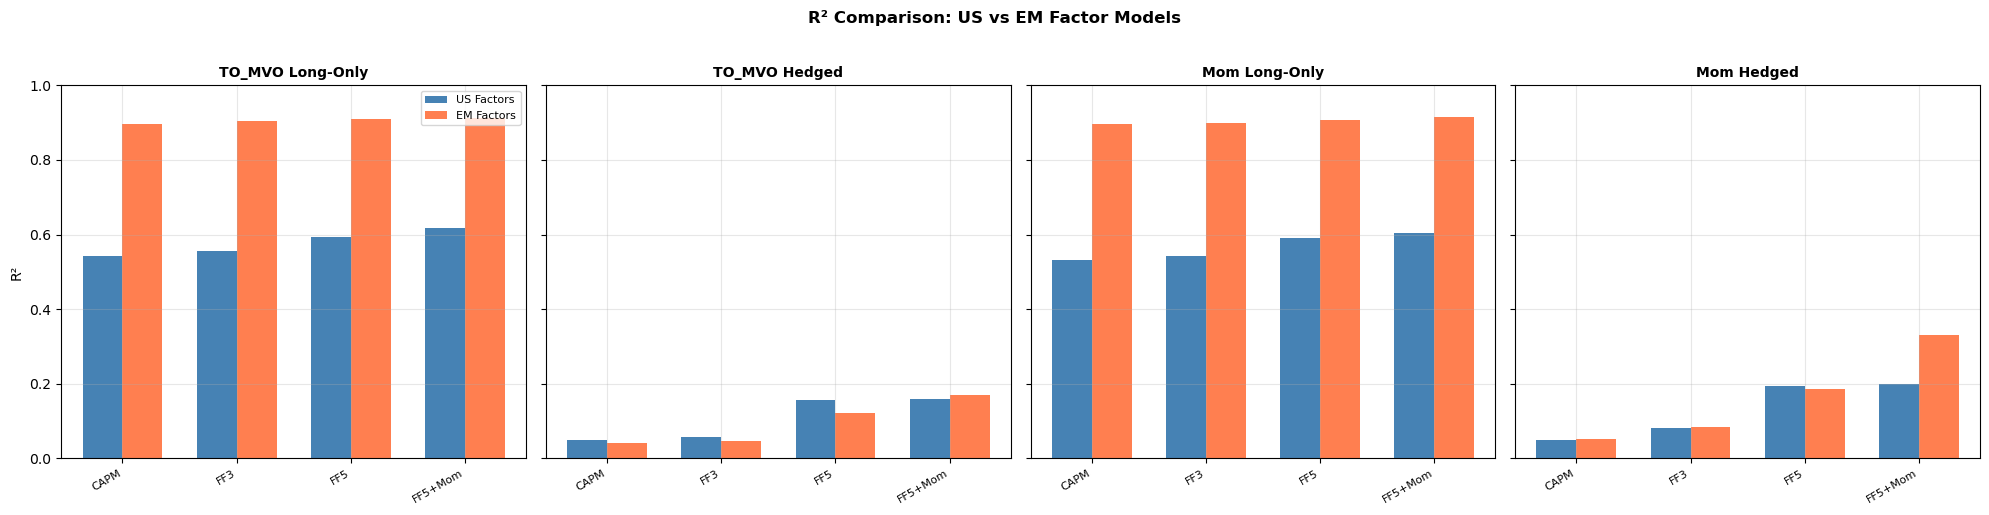

In [10]:
# R-squared comparison: US vs EM factors
r2_comparison = []
for sname, scol in STRATEGIES.items():
    y = strat[scol].dropna()
    cidx = y.index.intersection(us.index).intersection(em.index)
    y_c = y.loc[cidx]
    
    for spec_name, factors in SPECS.items():
        X_us = sm.add_constant(us.loc[cidx, factors])
        m_us = sm.OLS(y_c, X_us).fit()
        
        X_em = sm.add_constant(em.loc[cidx, factors])
        m_em = sm.OLS(y_c, X_em).fit()
        
        r2_comparison.append({
            'Strategy': sname,
            'Spec': spec_name,
            'R² (US)': m_us.rsquared,
            'R² (EM)': m_em.rsquared,
        })

r2_df = pd.DataFrame(r2_comparison)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, sname in enumerate(STRATEGIES.keys()):
    sub = r2_df[r2_df['Strategy'] == sname]
    x = np.arange(len(sub))
    w = 0.35
    axes[i].bar(x - w/2, sub['R² (US)'], w, label='US Factors', color='steelblue')
    axes[i].bar(x + w/2, sub['R² (EM)'], w, label='EM Factors', color='coral')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(sub['Spec'], rotation=30, ha='right', fontsize=8)
    axes[i].set_title(sname, fontweight='bold', fontsize=10)
    axes[i].set_ylim(0, 1)
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel('R²')
        axes[i].legend(fontsize=8)

plt.suptitle('R² Comparison: US vs EM Factor Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_rsq_comparison.pdf', bbox_inches='tight')
plt.show()

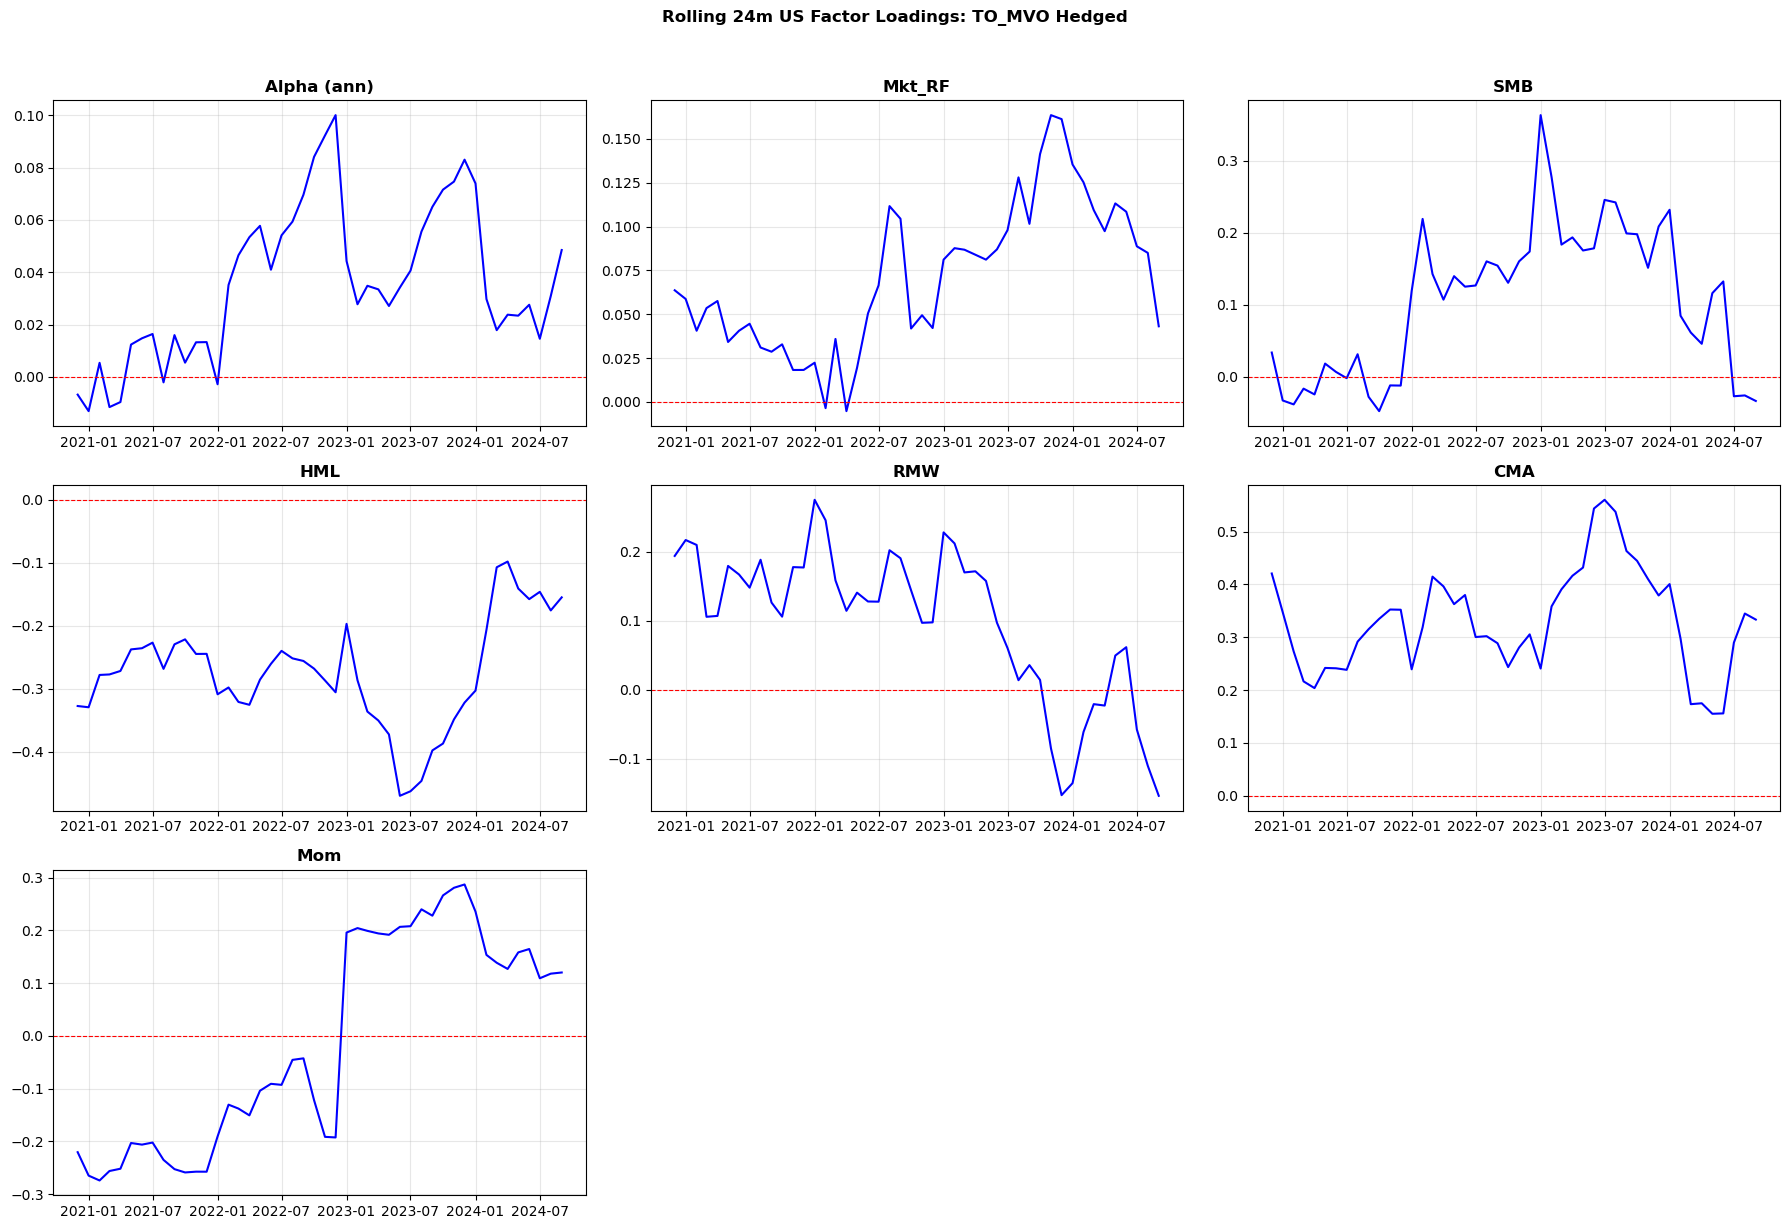

In [11]:
# Rolling 24-month US factor loadings for TO_MVO Hedged
sname_focus = 'TO_MVO Hedged'
scol_focus = STRATEGIES[sname_focus]
y_focus = strat[scol_focus].dropna()
cidx_focus = y_focus.index.intersection(us.index)
y_focus = y_focus.loc[cidx_focus]

roll_betas = {f: [] for f in US_FACTORS}
roll_betas['const'] = []
roll_dates_b = []

for i in range(ROLL_WIN, len(cidx_focus) + 1):
    window = cidx_focus[i - ROLL_WIN:i]
    y_w = y_focus.loc[window]
    X_w = sm.add_constant(us.loc[window, US_FACTORS])
    try:
        m = sm.OLS(y_w, X_w).fit()
        for f in US_FACTORS:
            roll_betas[f].append(m.params[f])
        roll_betas['const'].append(m.params['const'] * 12)
        roll_dates_b.append(window[-1])
    except:
        pass

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flat

all_keys = ['const'] + US_FACTORS
labels = ['Alpha (ann)'] + US_FACTORS
for i, (key, label) in enumerate(zip(all_keys, labels)):
    ax = axes[i]
    vals = roll_betas[key]
    ax.plot(roll_dates_b, vals, 'b-', lw=1.5)
    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_title(f'{label}', fontweight='bold')
    ax.grid(True, alpha=0.3)

for j in range(len(all_keys), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Rolling {ROLL_WIN}m US Factor Loadings: {sname_focus}',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_rolling_us_loadings.pdf', bbox_inches='tight')
plt.show()

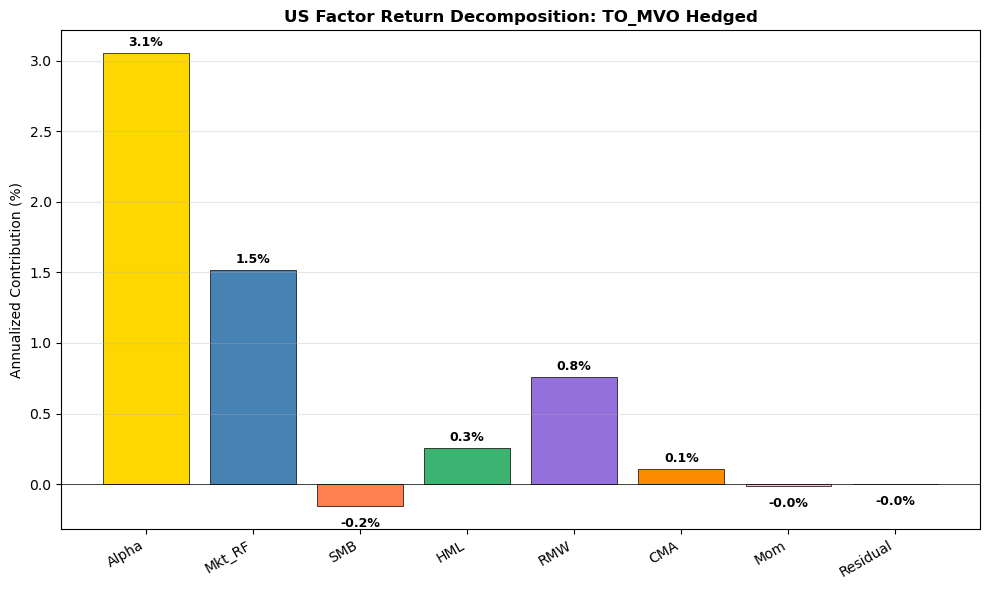


Return Decomposition (annualized %):
Alpha       3.06
Mkt_RF      1.52
SMB        -0.16
HML         0.25
RMW         0.76
CMA         0.10
Mom        -0.02
Residual   -0.00

Total strategy return: 5.52%


In [12]:
# US factor return decomposition for TO_MVO Hedged
y_dec = strat[scol_focus].dropna()
cidx_dec = y_dec.index.intersection(us.index)
y_dec = y_dec.loc[cidx_dec]
X_dec = sm.add_constant(us.loc[cidx_dec, US_FACTORS])
m_dec = sm.OLS(y_dec, X_dec).fit(cov_type='HC1')

# Decompose: total return = alpha + sum(beta_k * F_k) + residual
decomp = pd.DataFrame(index=cidx_dec)
decomp['Alpha'] = m_dec.params['const']
for f in US_FACTORS:
    decomp[f] = m_dec.params[f] * us.loc[cidx_dec, f]
decomp['Residual'] = m_dec.resid

ann_decomp = decomp.mean() * 12 * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['gold', 'steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'darkorange', 'pink', 'gray']
components = ['Alpha'] + US_FACTORS + ['Residual']
vals = [ann_decomp[c] for c in components]

bars = ax.bar(components, vals, color=colors[:len(components)], edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Annualized Contribution (%)')
ax.set_title(f'US Factor Return Decomposition: {sname_focus}', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, vals):
    ypos = bar.get_height()
    ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, ypos),
                xytext=(0, 5 if ypos >= 0 else -15), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

ax.set_xticklabels(components, rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_return_decomposition.pdf', bbox_inches='tight')
plt.show()

print('\nReturn Decomposition (annualized %):')
print(ann_decomp.round(2).to_string())
print(f'\nTotal strategy return: {y_dec.mean() * 1200:.2f}%')

## 7. Efficient Frontier and Portfolio Improvement

For a US investor holding the US market portfolio, how does adding the
EM hedged strategy improve the risk-return profile?

We construct the two-asset efficient frontier (US market + EM hedged)
and evaluate portfolio metrics at various allocation levels using
risk aversion $\lambda = 2.5$. The low correlation between the EM hedged
strategy and US equities creates substantial curvature in the frontier,
meaning even modest allocations can reduce portfolio volatility.

In [13]:
LAMBDA = 2.5

# Two-asset problem: US market (Mkt_RF) and EM hedged (A_hedged_eem)
em_h = strat['A_hedged_eem'].dropna()
us_m = us['Mkt_RF']
cidx_opt = em_h.index.intersection(us_m.index)
em_h = em_h.loc[cidx_opt]
us_m = us_m.loc[cidx_opt]

# Annualize
mu = np.array([us_m.mean() * 12, em_h.mean() * 12])
cov_monthly = np.cov(us_m, em_h)
Sigma = cov_monthly * 12

print('Expected Returns (annualized):')
print(f'  US Market:     {mu[0]*100:.2f}%')
print(f'  EM Hedged:     {mu[1]*100:.2f}%')
print(f'\nCorrelation: {np.corrcoef(us_m, em_h)[0,1]:.3f}')
print(f'\nAnnualized Covariance Matrix:')
print(pd.DataFrame(Sigma, index=['US_Mkt', 'EM_Hedged'], columns=['US_Mkt', 'EM_Hedged']).round(4))

# Portfolio improvement at various EM allocations
print(f'\nPortfolio Metrics at Various EM Allocations (lambda={LAMBDA}):')
print(f'{"EM Weight":>10s} {"US Weight":>10s} {"Ann Ret":>10s} {"Ann Vol":>10s} {"Sharpe":>8s} {"Vol Change":>12s}')
print('-' * 65)
vol_us_only = np.sqrt(Sigma[0, 0])
for w_em_pct in [0, 5, 10, 15, 20, 25, 50]:
    w = np.array([1 - w_em_pct/100, w_em_pct/100])
    r = w @ mu
    v = np.sqrt(w @ Sigma @ w)
    sr = r / v if v > 0 else 0
    vol_chg = (v / vol_us_only - 1) * 100
    print(f'{w_em_pct:>9d}% {100-w_em_pct:>9d}% {r*100:>9.2f}% {v*100:>9.2f}% {sr:>7.3f} {vol_chg:>+10.1f}%')

# Key insight: low correlation means vol drops even with small EM allocation
w_10 = np.array([0.90, 0.10])
port_ret_10 = w_10 @ mu
port_vol_10 = np.sqrt(w_10 @ Sigma @ w_10)
port_sr_10 = port_ret_10 / port_vol_10
print(f'\nAt 10% EM allocation: Vol reduction = {(1-port_vol_10/vol_us_only)*100:.1f}%, SR = {port_sr_10:.3f}')

Expected Returns (annualized):
  US Market:     15.23%
  EM Hedged:     5.52%

Correlation: 0.223

Annualized Covariance Matrix:
           US_Mkt  EM_Hedged
US_Mkt     0.0332     0.0027
EM_Hedged  0.0027     0.0044

Portfolio Metrics at Various EM Allocations (lambda=2.5):
 EM Weight  US Weight    Ann Ret    Ann Vol   Sharpe   Vol Change
-----------------------------------------------------------------
        0%       100%     15.23%     18.23%   0.835       +0.0%
        5%        95%     14.74%     17.39%   0.847       -4.6%
       10%        90%     14.26%     16.57%   0.860       -9.1%
       15%        85%     13.77%     15.75%   0.874      -13.6%
       20%        80%     13.28%     14.94%   0.889      -18.1%
       25%        75%     12.80%     14.14%   0.905      -22.4%
       50%        50%     10.37%     10.38%   0.999      -43.1%

At 10% EM allocation: Vol reduction = 9.1%, SR = 0.860


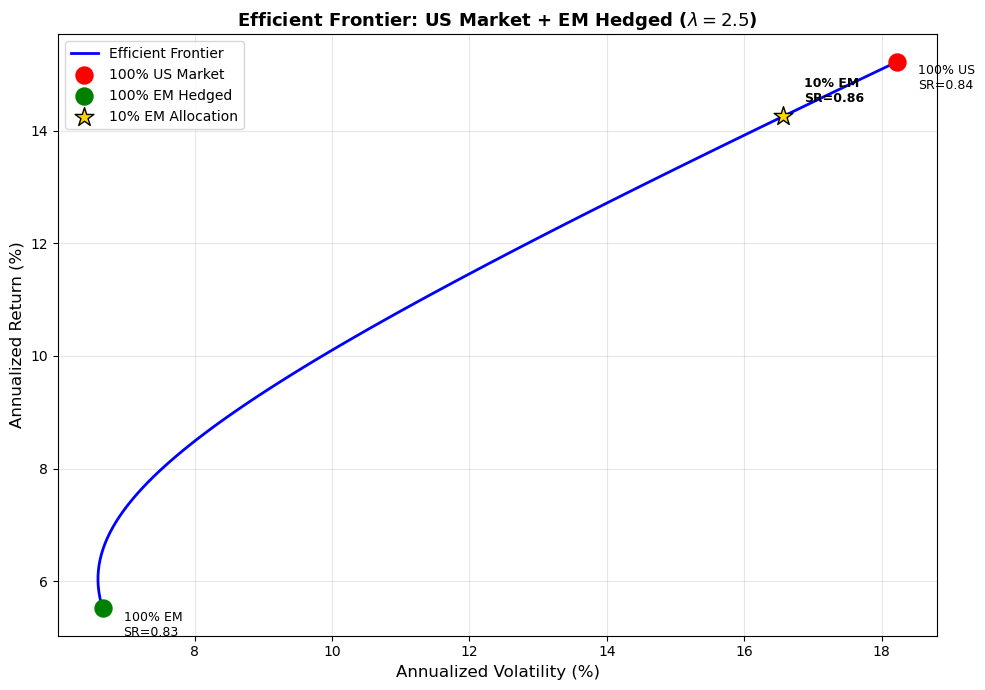

In [14]:
# Efficient frontier
weights_em = np.linspace(0, 1, 101)
frontier_ret = []
frontier_vol = []

for w_em in weights_em:
    w = np.array([1 - w_em, w_em])
    r = w @ mu
    v = np.sqrt(w @ Sigma @ w)
    frontier_ret.append(r * 100)
    frontier_vol.append(v * 100)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(frontier_vol, frontier_ret, 'b-', lw=2, label='Efficient Frontier')

# Mark key points
us_only_vol = np.sqrt(Sigma[0, 0]) * 100
us_only_ret = mu[0] * 100
em_only_vol = np.sqrt(Sigma[1, 1]) * 100
em_only_ret = mu[1] * 100

ax.scatter(us_only_vol, us_only_ret, s=150, c='red', zorder=5, label='100% US Market')
ax.scatter(em_only_vol, em_only_ret, s=150, c='green', zorder=5, label='100% EM Hedged')

# Mark 10% EM allocation
w_10_pt = np.array([0.90, 0.10])
vol_10_pt = np.sqrt(w_10_pt @ Sigma @ w_10_pt) * 100
ret_10_pt = (w_10_pt @ mu) * 100
sr_10_pt = ret_10_pt / vol_10_pt
ax.scatter(vol_10_pt, ret_10_pt, s=200, c='gold', marker='*', zorder=5, edgecolors='black',
           label='10% EM Allocation')

ax.annotate(f'100% US\nSR={us_only_ret/us_only_vol:.2f}',
            xy=(us_only_vol, us_only_ret), xytext=(15, -20),
            textcoords='offset points', fontsize=9)
ax.annotate(f'100% EM\nSR={em_only_ret/em_only_vol:.2f}',
            xy=(em_only_vol, em_only_ret), xytext=(15, -20),
            textcoords='offset points', fontsize=9)
ax.annotate(f'10% EM\nSR={sr_10_pt:.2f}',
            xy=(vol_10_pt, ret_10_pt), xytext=(15, 10),
            textcoords='offset points', fontsize=9, fontweight='bold')

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.set_title(f'Efficient Frontier: US Market + EM Hedged ($\\lambda={LAMBDA}$)',
             fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_efficient_frontier.pdf', bbox_inches='tight')
plt.show()

# Save allocation table
alloc_df = pd.DataFrame({
    'EM Weight (%)': weights_em * 100,
    'US Weight (%)': (1 - weights_em) * 100,
    'Ann Return (%)': frontier_ret,
    'Ann Vol (%)': frontier_vol,
    'Sharpe': [r / v if v > 0 else 0 for r, v in zip(frontier_ret, frontier_vol)],
})
alloc_df.to_csv(f'{OUTPUT_DIR}/csv/nb19_optimal_allocation.csv', index=False)

## 8. Sub-Period Stability

Repeat hurdle Sharpe and alpha tests across different market regimes within OOS.

SUB-PERIOD STABILITY: TO_MVO Hedged (EEM)
                        N months  SR_EM  SR_US    rho  Hurdle SR  Premium Pass Hurdle  Alpha (ann %)  Alpha t-stat
Period                                                                                                            
2019-2020 (COVID)             24  1.031  1.181  0.395      0.467    0.564         YES         -0.681        -0.224
2021-2022 (Tightening)        24  0.994  0.032  0.202      0.007    0.987         YES         10.005         1.478
2023-2024 (Recovery)          21  0.403  1.572  0.082      0.129    0.274         YES          7.815         1.171


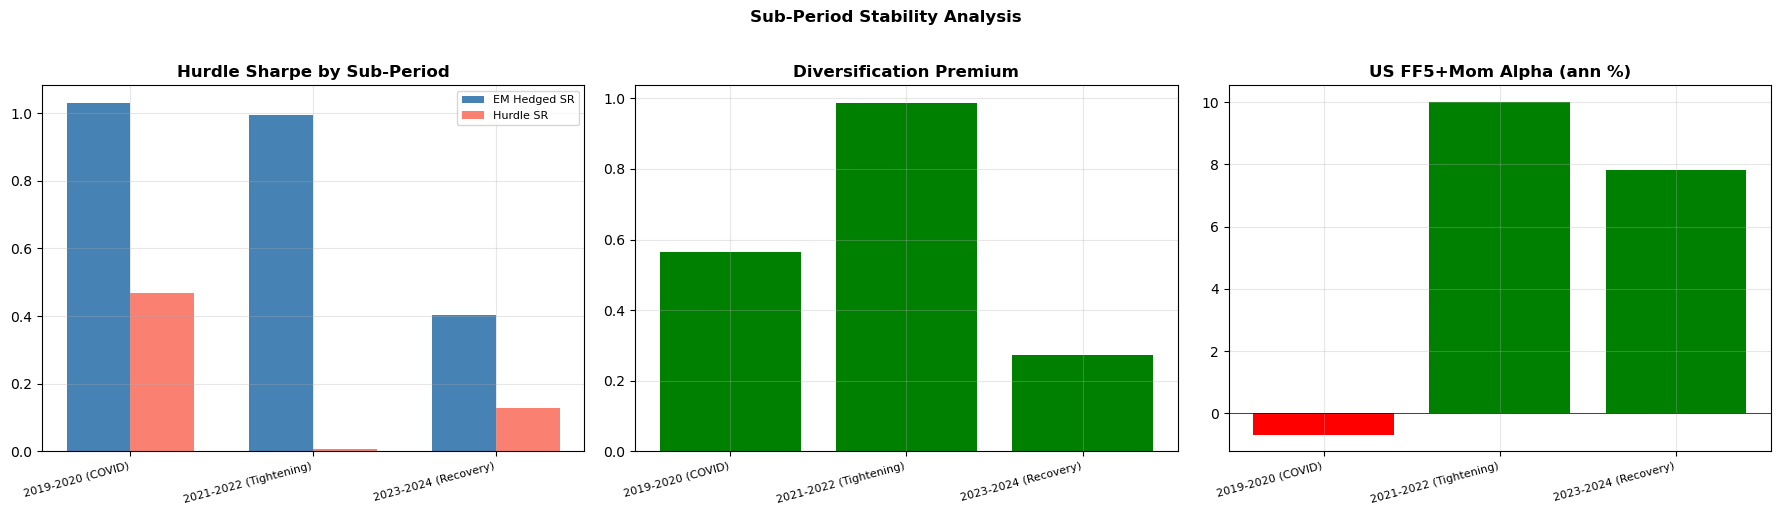

In [15]:
SUBPERIODS = {
    '2019-2020 (COVID)':       (pd.Timestamp('2019-01-01'), pd.Timestamp('2020-12-01')),
    '2021-2022 (Tightening)':  (pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-01')),
    '2023-2024 (Recovery)':    (pd.Timestamp('2023-01-01'), pd.Timestamp('2024-09-01')),
}

sub_results = []
focus_strat = 'A_hedged_eem'

for period_name, (start, end) in SUBPERIODS.items():
    mask = (strat.index >= start) & (strat.index <= end)
    s = strat.loc[mask, focus_strat].dropna()
    u = us.loc[(us.index >= start) & (us.index <= end)]
    e = em.loc[(em.index >= start) & (em.index <= end)]
    cidx = s.index.intersection(u.index).intersection(e.index)
    s = s.loc[cidx]
    u = u.loc[cidx]
    
    sr_em = ann_sharpe(s)
    sr_us = ann_sharpe(u['Mkt_RF'])
    rho = s.corr(u['Mkt_RF'])
    hurdle = sr_us * rho
    premium = sr_em - hurdle
    
    # Alpha test
    X = sm.add_constant(u[US_FACTORS])
    try:
        m = sm.OLS(s, X).fit(cov_type='HC1')
        alpha_ann = m.params['const'] * 1200
        alpha_t = m.tvalues['const']
    except:
        alpha_ann = np.nan
        alpha_t = np.nan
    
    sub_results.append({
        'Period': period_name,
        'N months': len(cidx),
        'SR_EM': sr_em,
        'SR_US': sr_us,
        'rho': rho,
        'Hurdle SR': hurdle,
        'Premium': premium,
        'Pass Hurdle': 'YES' if sr_em > hurdle else 'NO',
        'Alpha (ann %)': alpha_ann,
        'Alpha t-stat': alpha_t,
    })

sub_df = pd.DataFrame(sub_results).set_index('Period')
print('=' * 100)
print('SUB-PERIOD STABILITY: TO_MVO Hedged (EEM)')
print('=' * 100)
print(sub_df.round(3).to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: SR comparison
ax = axes[0]
x = np.arange(len(sub_df))
w = 0.35
ax.bar(x - w/2, sub_df['SR_EM'], w, label='EM Hedged SR', color='steelblue')
ax.bar(x + w/2, sub_df['Hurdle SR'], w, label='Hurdle SR', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(sub_df.index, rotation=15, ha='right', fontsize=8)
ax.set_title('Hurdle Sharpe by Sub-Period', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Diversification premium
ax = axes[1]
colors = ['green' if p > 0 else 'red' for p in sub_df['Premium']]
ax.bar(x, sub_df['Premium'], color=colors)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(sub_df.index, rotation=15, ha='right', fontsize=8)
ax.set_title('Diversification Premium', fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 3: Alpha
ax = axes[2]
colors_a = ['green' if a > 0 else 'red' for a in sub_df['Alpha (ann %)']]
ax.bar(x, sub_df['Alpha (ann %)'], color=colors_a)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(sub_df.index, rotation=15, ha='right', fontsize=8)
ax.set_title('US FF5+Mom Alpha (ann %)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Sub-Period Stability Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_subperiod_stability.pdf', bbox_inches='tight')
plt.show()

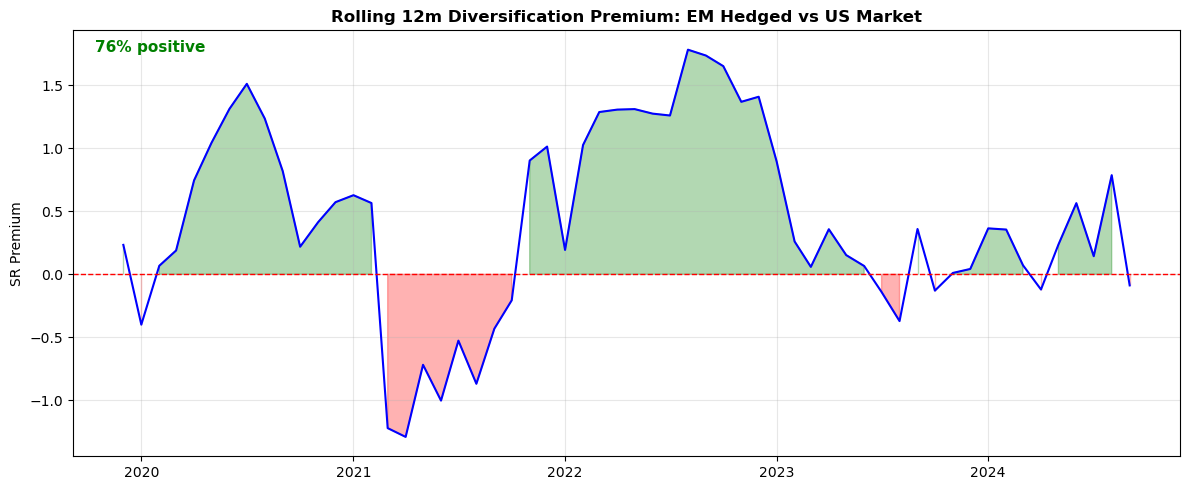

In [16]:
# Rolling 12-month diversification premium
ROLL_DIV = 12

em_h_full = strat['A_hedged_eem'].dropna()
cidx_r = em_h_full.index.intersection(us.index)
em_h_full = em_h_full.loc[cidx_r]
us_mkt_full = us.loc[cidx_r, 'Mkt_RF']

roll_premium = []
roll_dates_p = []

for i in range(ROLL_DIV, len(cidx_r) + 1):
    window = cidx_r[i - ROLL_DIV:i]
    sr_e = ann_sharpe(em_h_full.loc[window])
    sr_u = ann_sharpe(us_mkt_full.loc[window])
    rho_w = em_h_full.loc[window].corr(us_mkt_full.loc[window])
    hurdle_w = sr_u * rho_w
    roll_premium.append(sr_e - hurdle_w)
    roll_dates_p.append(window[-1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(roll_dates_p, roll_premium, 'b-', lw=1.5)
ax.axhline(0, color='red', ls='--', lw=1)
ax.fill_between(roll_dates_p, 0, roll_premium,
                where=[p > 0 for p in roll_premium], alpha=0.3, color='green')
ax.fill_between(roll_dates_p, 0, roll_premium,
                where=[p <= 0 for p in roll_premium], alpha=0.3, color='red')
ax.set_title(f'Rolling {ROLL_DIV}m Diversification Premium: EM Hedged vs US Market',
             fontweight='bold')
ax.set_ylabel('SR Premium')
ax.grid(True, alpha=0.3)

pos_pct = sum(1 for p in roll_premium if p > 0) / len(roll_premium) * 100
ax.annotate(f'{pos_pct:.0f}% positive', xy=(0.02, 0.95),
            xycoords='axes fraction', fontsize=11, fontweight='bold',
            color='green' if pos_pct > 50 else 'red')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb19_rolling_premium.pdf', bbox_inches='tight')
plt.show()

## 9. Summary

In [17]:
# Master summary table
print('=' * 90)
print('MASTER SUMMARY: US PORTFOLIO DIVERSIFICATION VALUE')
print('=' * 90)

# Primary strategy: TO_MVO Hedged (EEM)
em_h_s = strat['A_hedged_eem'].dropna()
cidx_s = em_h_s.index.intersection(us.index)
em_h_s = em_h_s.loc[cidx_s]
us_mkt_s = us.loc[cidx_s, 'Mkt_RF']

sr_em_s = ann_sharpe(em_h_s)
sr_us_s = ann_sharpe(us_mkt_s)
rho_s = em_h_s.corr(us_mkt_s)
hurdle_s = sr_us_s * rho_s

X_s = sm.add_constant(us.loc[cidx_s, US_FACTORS])
m_s = sm.OLS(em_h_s, X_s).fit(cov_type='HC1')

summary_data = {
    'EM Hedged Sharpe (OOS)': f'{sr_em_s:.3f}',
    'US Market Sharpe (OOS)': f'{sr_us_s:.3f}',
    'Correlation (EM Hedged, US Mkt)': f'{rho_s:.3f}',
    'Hurdle Sharpe': f'{hurdle_s:.3f}',
    'Diversification Premium': f'{sr_em_s - hurdle_s:.3f}',
    'Pass Hurdle Sharpe': 'YES' if sr_em_s > hurdle_s else 'NO',
    'US Alpha (ann bps, FF5+Mom)': f'{m_s.params["const"]*12*10000:.0f}',
    'US Alpha t-stat': f'{m_s.tvalues["const"]:.2f}',
    'US Alpha p-value': f'{m_s.pvalues["const"]:.4f}',
    'R² (US FF5+Mom)': f'{m_s.rsquared:.3f}',
}

# Compute portfolio metrics at 10% EM allocation
w_10 = np.array([0.90, 0.10])
vol_us_only = np.sqrt(Sigma[0, 0])
vol_10 = np.sqrt(w_10 @ Sigma @ w_10)
ret_10 = w_10 @ mu
sr_10 = ret_10 / vol_10
vol_reduction = (1 - vol_10 / vol_us_only) * 100

summary_data['Vol Reduction at 10% EM (%)'] = f'{vol_reduction:.1f}'
summary_data['10% EM Portfolio SR'] = f'{sr_10:.3f}'
summary_data['10% EM Portfolio Return (ann %)'] = f'{ret_10*100:.2f}'

for k, v in summary_data.items():
    print(f'  {k:40s} {v}')

pd.DataFrame(list(summary_data.items()),
             columns=['Metric', 'Value']).to_csv(
    f'{OUTPUT_DIR}/csv/nb19_summary.csv', index=False)

print('\n--- Conclusion ---')
if sr_em_s > hurdle_s:
    print(f'The EM hedged strategy PASSES the hurdle Sharpe test with a premium of '
          f'{sr_em_s - hurdle_s:.3f}.')
else:
    print(f'The EM hedged strategy FAILS the hurdle Sharpe test.')

if m_s.pvalues['const'] < 0.10:
    print(f'Alpha is statistically significant at the 10% level '
          f'({m_s.params["const"]*1200:.1f}% ann, t={m_s.tvalues["const"]:.2f}).')
else:
    print(f'Alpha is not statistically significant at the 10% level '
          f'({m_s.params["const"]*1200:.1f}% ann, t={m_s.tvalues["const"]:.2f}).')

print(f'\nAt a 10% EM allocation, portfolio vol decreases by {vol_reduction:.1f}% ')
print(f'with SR of {sr_10:.3f} (US-only SR: {sr_us_s:.3f}).')
print(f'The low correlation ({rho_s:.3f}) makes the EM hedged strategy a valuable ')
print(f'portable alpha overlay for diversifying US equity portfolios.')

MASTER SUMMARY: US PORTFOLIO DIVERSIFICATION VALUE
  EM Hedged Sharpe (OOS)                   0.828
  US Market Sharpe (OOS)                   0.835
  Correlation (EM Hedged, US Mkt)          0.223
  Hurdle Sharpe                            0.187
  Diversification Premium                  0.642
  Pass Hurdle Sharpe                       YES
  US Alpha (ann bps, FF5+Mom)              306
  US Alpha t-stat                          0.96
  US Alpha p-value                         0.3367
  R² (US FF5+Mom)                          0.158
  Vol Reduction at 10% EM (%)              9.1
  10% EM Portfolio SR                      0.860
  10% EM Portfolio Return (ann %)          14.26

--- Conclusion ---
The EM hedged strategy PASSES the hurdle Sharpe test with a premium of 0.642.
Alpha is not statistically significant at the 10% level (3.1% ann, t=0.96).

At a 10% EM allocation, portfolio vol decreases by 9.1% 
with SR of 0.860 (US-only SR: 0.835).
The low correlation (0.223) makes the EM hedged 